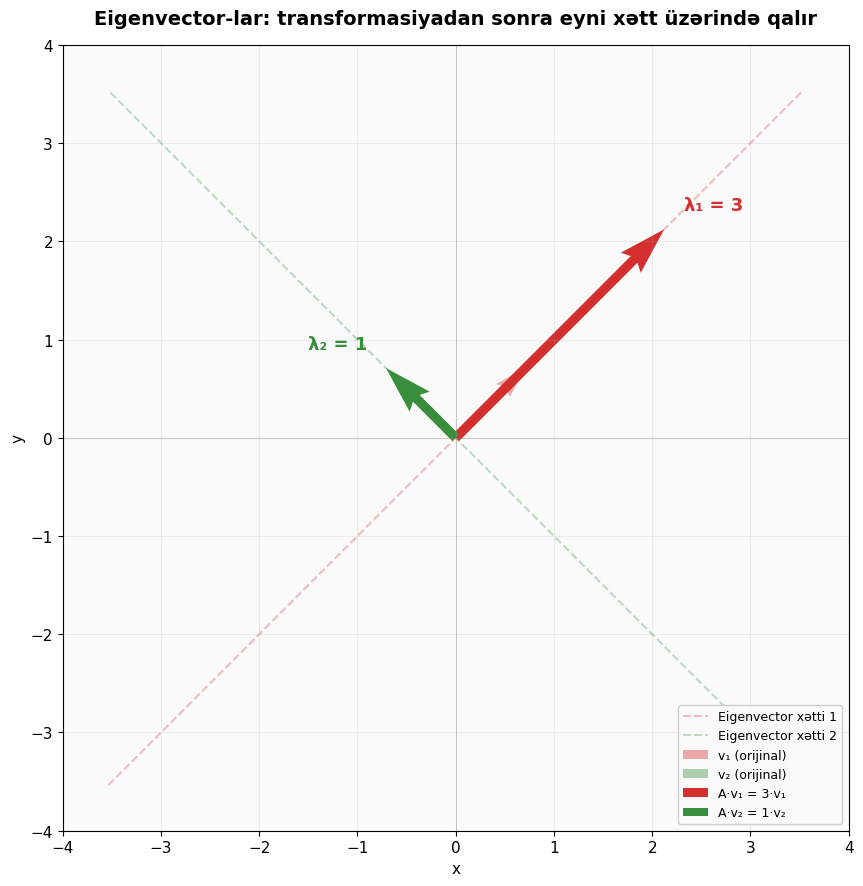

In [10]:
import numpy as np
import matplotlib.pyplot as plt

# Stil seçimi — təmiz, professional görünüş
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.size'] = 11

# Matris və eigenvector-lar
A = np.array([[2, 1], [1, 2]])
eigenvalues, eigenvectors = np.linalg.eig(A)

# Eigenvalue-ları azalan sıraya düz (böyük eigenvalue qırmızı olsun)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

v1 = eigenvectors[:, 0]   # λ=3 olan
v2 = eigenvectors[:, 1]   # λ=1 olan
lam1, lam2 = eigenvalues

# Transformasiyadan sonra
Av1 = A @ v1
Av2 = A @ v2

# ŞƏKİL
fig, ax = plt.subplots(figsize=(9, 9))

# 1. Eigenvector xətləri (kəsik) — sonsuza uzanır
t = np.linspace(-5, 5, 100)
ax.plot(t * v1[0], t * v1[1], '--', color='#d32f2f', alpha=0.3, linewidth=1.5,
        label='Eigenvector xətti 1')
ax.plot(t * v2[0], t * v2[1], '--', color='#388e3c', alpha=0.3, linewidth=1.5,
        label='Eigenvector xətti 2')

# 2. Orijinal eigenvector-lar (solğun)
ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
          color='#d32f2f', alpha=0.4, width=0.008,
          label=f'v₁ (orijinal)')
ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
          color='#388e3c', alpha=0.4, width=0.008,
          label=f'v₂ (orijinal)')

# 3. Transformasiyadan sonrakı eigenvector-lar (qalın, parlaq)
ax.quiver(0, 0, Av1[0], Av1[1], angles='xy', scale_units='xy', scale=1,
          color='#d32f2f', width=0.012,
          label=f'A·v₁ = {lam1:.0f}·v₁')
ax.quiver(0, 0, Av2[0], Av2[1], angles='xy', scale_units='xy', scale=1,
          color='#388e3c', width=0.012,
          label=f'A·v₂ = {lam2:.0f}·v₂')

# Annotation — eigenvalue-ları oxların yanında yaz
ax.annotate(f'λ₁ = {lam1:.0f}', xy=(Av1[0], Av1[1]), 
            xytext=(Av1[0]+0.2, Av1[1]+0.2),
            fontsize=13, fontweight='bold', color='#d32f2f')
ax.annotate(f'λ₂ = {lam2:.0f}', xy=(Av2[0], Av2[1]),
            xytext=(Av2[0]-0.8, Av2[1]+0.2),
            fontsize=13, fontweight='bold', color='#388e3c')

# Oxlar və grid
ax.set_xlim(-4, 4)
ax.set_ylim(-4, 4)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')

# Başlıq və açıqlama
ax.set_title('Eigenvector-lar: transformasiyadan sonra eyni xətt üzərində qalır',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('x', fontsize=11)
ax.set_ylabel('y', fontsize=11)
ax.legend(loc='lower right', framealpha=0.95, fontsize=9)

plt.tight_layout()
plt.savefig('eigenvector_main.png', dpi=150, bbox_inches='tight')  # GitHub üçün
plt.show()

### Nə görürük?

Şəkildə **A = [[2,1],[1,2]]** matrisinin iki eigenvector-u göstərilir:

- **Qırmızı ox** (v₁): [1,1] istiqamətində, λ₁ = 3 ilə **3 dəfə uzanır**. Kəsik qırmızı xətt — eigenvector-un üzərində qaldığı sonsuz xətdir.
- **Yaşıl ox** (v₂): [-1,1] istiqamətində, λ₂ = 1 ilə **dəyişməz qalır** (uzunluğu eynidir).

Hər iki halda diqqət edilməli olan əsas məqam: **istiqamət xətti dəyişmir**. Orijinal və transformasiyadan sonrakı vektorlar eyni kəsik xətt üzərindədir.

### Riyazi məna

Bu, eigenvector tərifinin vizual təsdiqidir:

$$A \cdot v = \lambda \cdot v$$

Yəni matris A vektora tətbiq edildikdə nəticə həmin vektorun skalyar (λ) qatından başqa bir şey deyil. Bu, A matrisinin v istiqamətində sırf **uzanma/sıxılma** kimi davrandığını göstərir — heç bir fırlanma yoxdur.

### Niyə vacibdir?

Eigenvector-lar bir matrisin **təbii oxlarıdır**. Onları bilməklə:

- Mürəkkəb transformasiyanı sadə uzanmalar şəklində başa düşmək olur
- Datanın əsas istiqamətlərini tapmaq mümkün olur (PCA — aşağıda baxılır)
- ML-də ölçü azaltma, görüntü emalı, və tövsiyə sistemləri bu prinsipə əsaslanır

[[2,1],[1,2]] simmetrik matrisdir, deməli eigenvector-ları bir-birinə **ortoqonaldır** (90° bucaq) — bu, covariance matrislərinin və PCA-nın işləməsinin əsas səbəbidir.

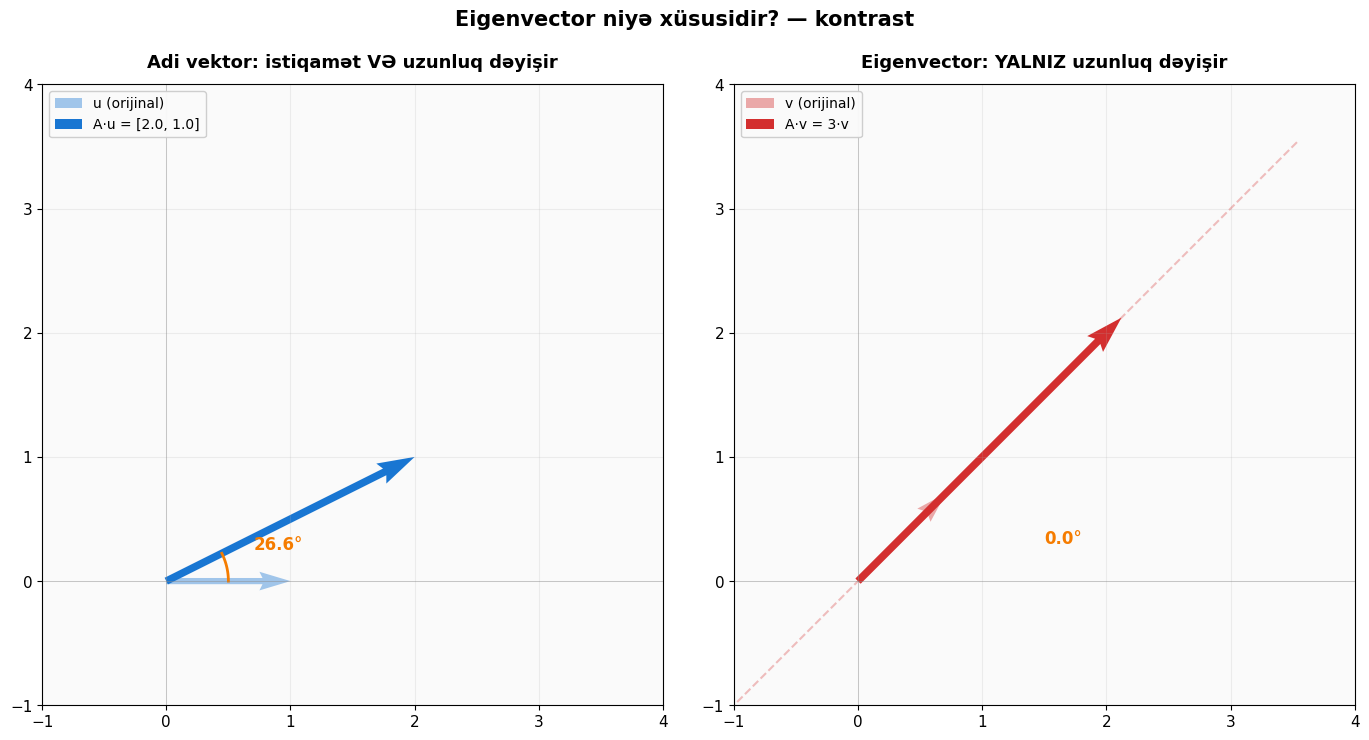


📊 MÜQAYİSƏ:
Adi vektor u = [1, 0]:
  → A·u = [2. 1.]
  → Bucaq dəyişikliyi: 26.57°
  → Uzunluq: 1.000 → 2.236

Eigenvector v:
  → A·v = [2.12132034 2.12132034]
  → Bucaq dəyişikliyi: 0.00°
  → Uzunluq: 1.000 → 3.000


In [11]:
import numpy as np
import matplotlib.pyplot as plt

# Stil
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.size'] = 11

# Matris və eigenvector
A = np.array([[2, 1], [1, 2]])
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]
v = eigenvectors[:, 0]   # qırmızı eigenvector (λ=3)
lam = eigenvalues[0]

# Adi vektor — eigenvector DEYİL
u = np.array([1.0, 0.0])

# Transformasiyadan sonra
Au = A @ u
Av = A @ v

# Bucaq hesablamaq üçün funksiya
def bucaq_derece(a, b):
    cos_t = np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b))
    cos_t = np.clip(cos_t, -1, 1)
    return np.degrees(np.arccos(cos_t))

bucaq_u = bucaq_derece(u, Au)
bucaq_v = bucaq_derece(v, Av)

# İKİ ŞƏKİL YAN-YANA
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ========== SOL: ADI VEKTOR (mavi) ==========
ax = axes[0]

# Orijinal mavi vektor (solğun)
ax.quiver(0, 0, u[0], u[1], angles='xy', scale_units='xy', scale=1,
          color='#1976d2', alpha=0.4, width=0.010,
          label='u (orijinal)')

# Transformasiyadan sonra (parlaq)
ax.quiver(0, 0, Au[0], Au[1], angles='xy', scale_units='xy', scale=1,
          color='#1976d2', width=0.012,
          label=f'A·u = {Au.tolist()}')

# Bucaq qövsü göstərmək üçün
theta_start = 0
theta_end = np.radians(bucaq_u)
arc_r = 0.5
arc_t = np.linspace(theta_start, theta_end, 30)
ax.plot(arc_r * np.cos(arc_t), arc_r * np.sin(arc_t),
        color='#f57c00', linewidth=2)
ax.text(0.7, 0.25, f'{bucaq_u:.1f}°', fontsize=12, fontweight='bold',
        color='#f57c00')

ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
ax.set_title('Adi vektor: istiqamət VƏ uzunluq dəyişir',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# ========== SAĞ: EIGENVECTOR (qırmızı) ==========
ax = axes[1]

# Eigenvector xətti (arxa fonda)
t = np.linspace(-5, 5, 100)
ax.plot(t * v[0], t * v[1], '--', color='#d32f2f', alpha=0.3, linewidth=1.5)

# Orijinal eigenvector (solğun)
ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
          color='#d32f2f', alpha=0.4, width=0.010,
          label='v (orijinal)')

# Transformasiyadan sonra (parlaq)
ax.quiver(0, 0, Av[0], Av[1], angles='xy', scale_units='xy', scale=1,
          color='#d32f2f', width=0.012,
          label=f'A·v = {lam:.0f}·v')

# Bucaq göstərmək — burada 0°
ax.text(1.5, 0.3, f'{bucaq_v:.1f}°', fontsize=12, fontweight='bold',
        color='#f57c00')

ax.set_xlim(-1, 4)
ax.set_ylim(-1, 4)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
ax.set_title('Eigenvector: YALNIZ uzunluq dəyişir',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# Ümumi başlıq
fig.suptitle('Eigenvector niyə xüsusidir? — kontrast',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('eigenvector_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Statistika çap et
print(f"\n📊 MÜQAYİSƏ:")
print(f"Adi vektor u = [1, 0]:")
print(f"  → A·u = {Au}")
print(f"  → Bucaq dəyişikliyi: {bucaq_u:.2f}°")
print(f"  → Uzunluq: {np.linalg.norm(u):.3f} → {np.linalg.norm(Au):.3f}")
print(f"\nEigenvector v:")
print(f"  → A·v = {Av}")
print(f"  → Bucaq dəyişikliyi: {bucaq_v:.2f}°")
print(f"  → Uzunluq: {np.linalg.norm(v):.3f} → {np.linalg.norm(Av):.3f}")

### Nə görürük?

İki şəkil yan-yana — eyni A = [[2,1],[1,2]] matrisi iki fərqli vektora tətbiq olunur:

- **Sol (mavi, adi vektor)**: u = [1, 0] vektoru transformasiyadan sonra [2, 1] olur. İstiqamət **26.6°** fırlanır, uzunluq isə 1-dən √5 ≈ 2.24-ə qədər artır. Yəni vektor həm yön dəyişir, həm uzanır.
- **Sağ (qırmızı, eigenvector)**: v vektoru transformasiyadan sonra eyni kəsik xətt üzərində qalır. Bucaq dəyişikliyi **0.0°**, uzunluq isə tam λ = 3 dəfə artır.

### Riyazi məna

Eigenvector tərifi yalnız xüsusi vektorlar üçün doğrudur. **Adi vektorlar üçün** transformasiya iki effekt yaradır:

$$A \cdot u = (\text{uzanma}) + (\text{fırlanma})$$

**Eigenvector-lar üçün** isə fırlanma komponenti sıfırdır:

$$A \cdot v = \lambda \cdot v \quad (\text{yalnız uzanma})$$

Bu, eigenvector-un nə olduğunun ən dəqiq tərifidir: **A matrisi tərəfindən fırlanmayan vektor**.

### Niyə vacibdir?

2D müstəvidə sonsuz sayda vektor var, amma A matrisi yalnız **2 xüsusi istiqaməti** dəyişməz qoyur — eigenvector xətləri. Qalan bütün istiqamətlər həm fırlanır, həm uzanır.

Bu fakt aşağıdakı tətbiqlərin əsasıdır:

- **Diaqonalizasiya**: matrisi eigenvector əsasında yazıb mürəkkəb hesablamaları sadələşdirmək
- **Dinamik sistemlər**: zaman keçdikcə sistemin hansı istiqamətdə inkişaf edəcəyini proqnozlaşdırmaq
- **PCA**: datanın "fırlanmayan" oxlarını tapmaq (növbəti bölmədə baxılır)

Yəni eigenvector-lar matrisin **gizli skeletini** açır — onları bilməklə transformasiyanın bütün davranışını proqnozlaşdırmaq olur.

GIF yazılır... (10-20 saniyə çəkə bilər)
✅ Hazır: eigenvector_animation.gif


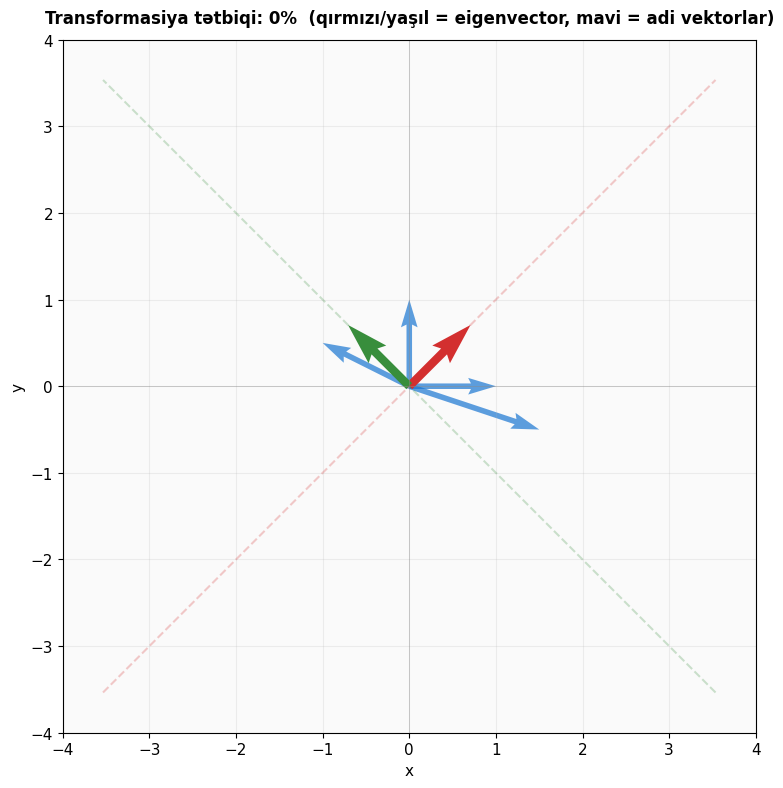

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from IPython.display import HTML
HTML(anim.to_jshtml())

# Stil
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.size'] = 11

# Matris və eigenvector-lar
A = np.array([[2.0, 1.0], [1.0, 2.0]])
I = np.eye(2)
eigenvalues, eigenvectors = np.linalg.eig(A)
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

v1 = eigenvectors[:, 0]   # λ=3
v2 = eigenvectors[:, 1]   # λ=1

# Adi vektorlar — eigenvector OLMAYAN
# Bunlar eigenvector xətlərindən kənarda yerləşməlidir
adi_vektorlar = [
    np.array([1.0, 0.0]),
    np.array([0.0, 1.0]),
    np.array([1.5, -0.5]),
    np.array([-1.0, 0.5]),
]

# Fiqur qur
fig, ax = plt.subplots(figsize=(9, 9))

def cek_kadr(t):
    """Hər kadrda çağırılır. t: 0-dan 1-ə qədər."""
    ax.clear()
    
    # İnterpolasiya matrisi: M(t) = (1-t)·I + t·A
    M = (1 - t) * I + t * A
    
    # Eigenvector xətləri (arxa fonda, sabit)
    s = np.linspace(-5, 5, 100)
    ax.plot(s * v1[0], s * v1[1], '--', color='#d32f2f', alpha=0.25, linewidth=1.5)
    ax.plot(s * v2[0], s * v2[1], '--', color='#388e3c', alpha=0.25, linewidth=1.5)
    
    # Adi vektorları çək (mavi)
    for u in adi_vektorlar:
        Mu = M @ u
        ax.quiver(0, 0, Mu[0], Mu[1], angles='xy', scale_units='xy', scale=1,
                  color='#1976d2', alpha=0.7, width=0.008)
    
    # Eigenvector v1 (qırmızı)
    Mv1 = M @ v1
    ax.quiver(0, 0, Mv1[0], Mv1[1], angles='xy', scale_units='xy', scale=1,
              color='#d32f2f', width=0.012)
    
    # Eigenvector v2 (yaşıl)
    Mv2 = M @ v2
    ax.quiver(0, 0, Mv2[0], Mv2[1], angles='xy', scale_units='xy', scale=1,
              color='#388e3c', width=0.012)
    
    # Oxlar və grid
    ax.set_xlim(-4, 4)
    ax.set_ylim(-4, 4)
    ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    ax.grid(True, alpha=0.2)
    ax.set_aspect('equal')
    
    # Başlıq — t-dən asılı
    progress = int(t * 100)
    ax.set_title(f'Transformasiya tətbiqi: {progress}%  '
                 f'(qırmızı/yaşıl = eigenvector, mavi = adi vektorlar)',
                 fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')

# Kadr ardıcıllığı: 0-dan 1-ə qədər, sonra geriyə (gözəl loop üçün)
t_values = np.concatenate([
    np.linspace(0, 1, 40),      # irəli
    np.ones(10),                 # 100%-də dayan
    np.linspace(1, 0, 40),      # geri
    np.zeros(10),                # 0%-də dayan
])

anim = FuncAnimation(fig, cek_kadr, frames=t_values, interval=80, repeat=True)

# GIF kimi yadda saxla
print("GIF yazılır... (10-20 saniyə çəkə bilər)")
anim.save('eigenvector_animation.gif', writer=PillowWriter(fps=12), dpi=100)
print("✅ Hazır: eigenvector_animation.gif")

plt.show()

### Nə görürük?

Bu animasiya A = [[2,1],[1,2]] matrisinin **tədricən tətbiqini** göstərir — 0%-dən 100%-ə qədər. Hər kadrda tətbiq olunan matris belədir:

$$M(t) = (1-t) \cdot I + t \cdot A, \quad t \in [0, 1]$$

Yəni t=0 olanda heç bir transformasiya yoxdur (vahid matris), t=1 olanda isə A matrisi tam tətbiq olunur. Aradakı vəziyyətlər bu iki nöqtə arasındakı **kəsilməz keçidi** göstərir.

Animasiyada 6 vektor var:

- **2 eigenvector** (qırmızı və yaşıl): kəsik xətlər üzərində yerləşir
- **4 adi vektor** (mavi): müxtəlif istiqamətlərə baxır

### Diqqət ediləcək əsas məqam

Animasiya boyu **iki davranış formasını** müşahidə et:

1. **Qırmızı və yaşıl oxlar** kəsik xətlər üzərində **uzanır və sıxılır**, amma heç vaxt bu xətlərdən kənara çıxmırlar. Qırmızı (λ₁=3) 3 dəfəyə qədər uzanır; yaşıl (λ₂=1) eyni qalır.
2. **Mavi oxlar** isə həm istiqamət, həm uzunluq dəyişir — onlar müstəvidə **azad şəkildə hərəkət edir**.

Bu, eigenvector-un əsl tərifidir: **transformasiyanın bütün gedişində öz xəttini tərk etməyən vektor**.

### Riyazi məna

İnterpolasiya M(t) hər anda öz **eigenvector-larını saxlayır**, çünki:

$$M(t) \cdot v = (1-t) \cdot I \cdot v + t \cdot A \cdot v = (1-t) \cdot v + t \cdot \lambda \cdot v = [(1-t) + t\lambda] \cdot v$$

Yəni v vektoru M(t)-nin də eigenvector-udur, sadəcə eigenvalue zamanla **(1-t) + tλ** kimi dəyişir:

- t=0: eigenvalue = 1 (heç bir uzanma)
- t=1: eigenvalue = λ (tam uzanma)
- Arada: xətti keçid

Bu, eigenvector istiqamətinin **bütün ailə boyu sabit qaldığını** isbat edir.

### Niyə vacibdir?

Bu animasiya statik şəkillərdə görünməyən bir həqiqəti göstərir: eigenvector-lar **bütün transformasiya prosesi boyu** öz xətlərini saxlayır, sadəcə son nəticədə yox. Bu xüsusiyyət bir çox real tətbiqdə qarşımıza çıxır:

- **Dinamik sistemlər**: zamanla dəyişən sistemlərdə eigenvector istiqaməti sabit qalır, yalnız böyüklük dəyişir
- **Markov zəncirləri**: uzunmüddətli davranış sistemin **dominant eigenvector**-u ilə təyin olunur
- **İterativ alqoritmlər**: PageRank, power iteration, və PCA — hamısı eigenvector-un "cəlbedici" xüsusiyyətinə əsaslanır

Yəni eigenvector təkcə bir nöqtədə deyil, **bütün proses boyu** matrisin imzasını daşıyır.

---

## İndiyə qədər abstract matrislərlə işlədik. İndi datanı görək.

Yuxarıdakı bütün vizuallarda A matrisi **süni** idi — biz onu öyrənmək üçün seçmişdik. Amma real dünyada matrislər boş yerdə yaranmır: onlar **datadan** gəlir. Növbəti bölmədə görəcəyik ki, real datanın **covariance matrisinin eigenvector-ları** datanın özünün strukturunu açır.

Bu, PCA-nın (Principal Component Analysis) əsasıdır — və sənin statistika və ML karyeran boyunca ən çox istifadə edəcəyin alətlərdən biridir.

---

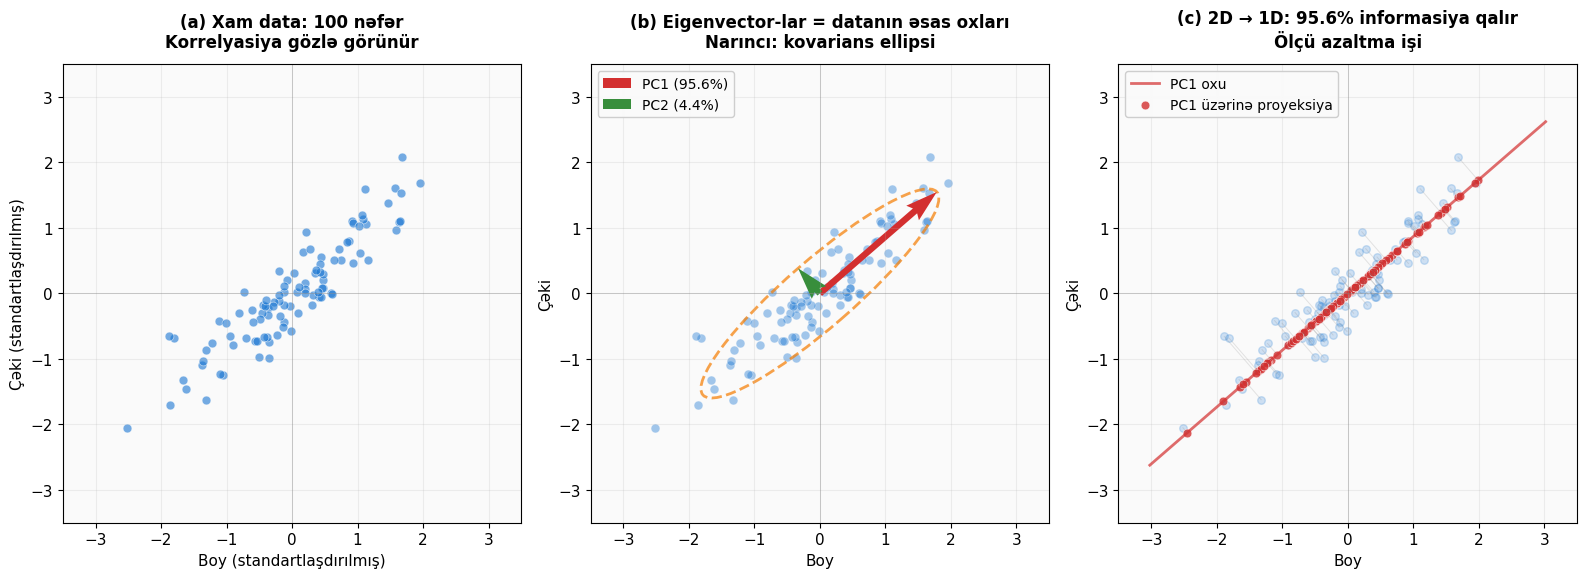

📊 PCA NƏTİCƏLƏRİ
Covariance matrisi:
[[0.82476989 0.65970044]
 [0.65970044 0.63700635]]

Eigenvalue-lar (azalan): [1.39723523 0.06454102]
Eigenvector-lar (sütun-sütun):
[[ 0.75527816 -0.65540438]
 [ 0.65540438  0.75527816]]

Yayılmanın payı:
  PC1: 95.58%
  PC2: 4.42%

💡 Yəni 2D data əslində ~96% bir xətt üzərindədir.
   2D → 1D azaltsaq, 4.4% informasiya itirilir.


In [13]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

# Stil
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.size'] = 11

# ==============================================
# 1. DATA YARAT — "boy/çəki" simulyasiyası
# ==============================================
np.random.seed(42)
n = 100

# Standartlaşdırılmış boy (ortalama 0, sapma 1)
boy = np.random.randn(n)
# Çəki boya bağlıdır + öz səs
ceki = 0.85 * boy + 0.35 * np.random.randn(n)

# Data matrisi: hər sətir bir nəfər, sütunlar [boy, çəki]
X = np.column_stack([boy, ceki])

# Mərkəzləşdir
X_centered = X - X.mean(axis=0)

# ==============================================
# 2. PCA — covariance + eigenvector
# ==============================================
C = (X_centered.T @ X_centered) / (n - 1)

eigenvalues, eigenvectors = np.linalg.eig(C)
# Azalan sıra
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# Faiz
total_var = eigenvalues.sum()
pc1_pct = eigenvalues[0] / total_var * 100
pc2_pct = eigenvalues[1] / total_var * 100

# ==============================================
# 3. PROYEKSİYA — hər nöqtəni PC1 üzərinə düşür
# ==============================================
pc1 = eigenvectors[:, 0]
# Hər nöqtənin PC1 üzərində koordinatı
proyeksiya_skalyar = X_centered @ pc1
# Bu skalyarları PC1 oxu üzərində geri qaytarmaq
proyeksiya_2d = np.outer(proyeksiya_skalyar, pc1)

# ==============================================
# 4. ŞƏKİL — 3 panel
# ==============================================
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))

# ----- PANEL A: Xam data -----
ax = axes[0]
ax.scatter(X_centered[:, 0], X_centered[:, 1], 
           alpha=0.6, s=40, color='#1976d2', edgecolor='white', linewidth=0.5)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_xlabel('Boy (standartlaşdırılmış)')
ax.set_ylabel('Çəki (standartlaşdırılmış)')
ax.set_title('(a) Xam data: 100 nəfər\nKorrelyasiya gözlə görünür',
             fontsize=12, fontweight='bold', pad=12)

# ----- PANEL B: Data + eigenvector oxları + ellips -----
ax = axes[1]
ax.scatter(X_centered[:, 0], X_centered[:, 1],
           alpha=0.4, s=40, color='#1976d2', edgecolor='white', linewidth=0.5)

# Yayılma ellipsi (covariance ellipsi)
# Ellipsin əsas oxları: 2*sqrt(eigenvalue) (2 sigma)
ell_width = 2 * 2 * np.sqrt(eigenvalues[0])
ell_height = 2 * 2 * np.sqrt(eigenvalues[1])
ell_angle = np.degrees(np.arctan2(pc1[1], pc1[0]))
ellipse = Ellipse(xy=(0, 0), width=ell_width, height=ell_height,
                  angle=ell_angle, facecolor='none', edgecolor='#f57c00',
                  linewidth=2, linestyle='--', alpha=0.7)
ax.add_patch(ellipse)

# Eigenvector oxları (uzunluq = 2·sqrt(λ))
for i in range(2):
    v = eigenvectors[:, i]
    scale = 2 * np.sqrt(eigenvalues[i])
    color = '#d32f2f' if i == 0 else '#388e3c'
    label = f'PC{i+1} ({[pc1_pct, pc2_pct][i]:.1f}%)'
    ax.quiver(0, 0, v[0]*scale, v[1]*scale,
              angles='xy', scale_units='xy', scale=1,
              color=color, width=0.014, label=label)

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_xlabel('Boy')
ax.set_ylabel('Çəki')
ax.set_title('(b) Eigenvector-lar = datanın əsas oxları\nNarıncı: kovarians ellipsi',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

# ----- PANEL C: PC1 oxuna proyeksiya -----
ax = axes[2]

# PC1 xətti (uzun)
t = np.linspace(-4, 4, 100)
ax.plot(t * pc1[0], t * pc1[1], '-', color='#d32f2f', linewidth=2, alpha=0.7,
        label='PC1 oxu')

# Hər nöqtədən proyeksiyaya qədər kəsik xətt
for i in range(n):
    ax.plot([X_centered[i, 0], proyeksiya_2d[i, 0]],
            [X_centered[i, 1], proyeksiya_2d[i, 1]],
            '-', color='gray', alpha=0.2, linewidth=0.7)

# Orijinal nöqtələr (solğun)
ax.scatter(X_centered[:, 0], X_centered[:, 1],
           alpha=0.2, s=30, color='#1976d2')

# Proyeksiya nöqtələri (qabarıq) — PC1 üzərində
ax.scatter(proyeksiya_2d[:, 0], proyeksiya_2d[:, 1],
           alpha=0.8, s=40, color='#d32f2f', edgecolor='white', linewidth=0.5,
           label=f'PC1 üzərinə proyeksiya')

ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.set_xlim(-3.5, 3.5)
ax.set_ylim(-3.5, 3.5)
ax.set_aspect('equal')
ax.grid(True, alpha=0.2)
ax.set_xlabel('Boy')
ax.set_ylabel('Çəki')
ax.set_title(f'(c) 2D → 1D: {pc1_pct:.1f}% informasiya qalır\nÖlçü azaltma işi',
             fontsize=12, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)

plt.tight_layout()
plt.savefig('pca_preview.png', dpi=150, bbox_inches='tight')
plt.show()

# ==============================================
# 5. STATİSTİKA ÇAP
# ==============================================
print("📊 PCA NƏTİCƏLƏRİ")
print("=" * 40)
print(f"Covariance matrisi:")
print(C)
print(f"\nEigenvalue-lar (azalan): {eigenvalues}")
print(f"Eigenvector-lar (sütun-sütun):")
print(eigenvectors)
print(f"\nYayılmanın payı:")
print(f"  PC1: {pc1_pct:.2f}%")
print(f"  PC2: {pc2_pct:.2f}%")
print(f"\n💡 Yəni 2D data əslində ~{pc1_pct:.0f}% bir xətt üzərindədir.")
print(f"   2D → 1D azaltsaq, {100-pc1_pct:.1f}% informasiya itirilir.")

### Nə görürük?

Üç panel **PCA-nın bütün axınını** göstərir:

**(a) Xam data**: 100 nəfərin standartlaşdırılmış boy və çəkisi. Mavi nöqtələr təsadüfi səpələnməyib — diaqonal şəkildə qruplaşıb. Bu, **korrelyasiyanın gözə görünən təzahürüdür**: boy artdıqca çəki də artır.

**(b) PCA strukturu**: Eyni data, amma üzərində üç yeni element:

- **Qırmızı ox (PC1, 95.6%)**: datanın **ən çox yayıldığı istiqamət**. Bu, kovarians matrisinin ən böyük eigenvalue-suna uyğun eigenvector-dur.
- **Yaşıl ox (PC2, 4.4%)**: PC1-ə **dik istiqamətdə** qalıq variasiya.
- **Narıncı ellips**: kovarians matrisinin həndəsi təsviri. Onun əsas oxları **dəqiq** eigenvector-lardır, uzunluqları isə 2σ (yəni 2·√λ).

**(c) Ölçü azaltma**: hər nöqtə PC1 oxuna **proyeksiya edilir** (qırmızı nöqtələr). Boz xətlər itirilən informasiyanı göstərir — yəni 2D-dən 1D-yə keçəndə nə qədər "kənarlaşma" buraxırıq. Bu kənarlaşma cəmi **4.4%** təşkil edir.

### Riyazi məna

PCA-nın əsas tənliyi:

$$C = \frac{1}{n-1} X^T X, \qquad C \cdot v_i = \lambda_i \cdot v_i$$

Burada **C kovarians matrisidir**, və onun eigenvector-ları (v₁, v₂) datanın əsas oxlarını verir. Hər eigenvalue (λᵢ) həmin ox üzrə yayılma miqdarını göstərir.

Vacib teorem: **simmetrik matrislərin eigenvector-ları bir-birinə ortoqonaldır**. Kovarians matrisi həmişə simmetrik olduğu üçün PC1 və PC2 həmişə **90° bucaqdadır**. Bu, PCA-nın işləməsinin əsasıdır — yeni oxlar tam müstəqil ölçülər yaradır.

Yayılmanın faizi:

$$\text{PC}_i \text{ faizi} = \frac{\lambda_i}{\sum_j \lambda_j} \times 100$$

Bizim datada PC1 = 95.6%, PC2 = 4.4%. Yəni 2D datanın **demək olar ki, bütün informasiyası bir xətt üzərindədir**.

### Niyə vacibdir?

Bu kiçik 2D nümunə real dünyadakı qaydanın miniatür versiyasıdır:

- **Şəkil emalı**: 1024×1024 piksel şəkil = 1M ölçü. PCA ilə ilk 50-100 komponent şəklin 95%-ni saxlayır. **Eigenfaces** sistemi məhz buna əsaslanır.
- **Genetika**: minlərlə gen ifadəsi → PCA ilə 2-3 əsas oxa endirilir, və populyasiya strukturu görünür (məs. coğrafi mənşə).
- **Maliyyə**: yüzlərlə səhmin gündəlik qiymət dəyişikliyi → ilk PC adətən **bazarın ümumi hərəkəti**, ikinci PC isə sektor fərqləri olur.
- **NLP**: word embedding-lərin PCA-sı sözlərin semantik əlaqələrini açır.

Statistika baxımından PCA həm də **multicollinearity** problemini həll edir: bir-biri ilə korrelyasiyalı dəyişənləri tam müstəqil komponentlərə çevirir. Reqressiya, klassifikasiya və klasterləşmədə bu, modelin sabitliyini artırır.

### Notebook-un əsas mesajı

Hissə 1-4-də abstract matrislərlə eigenvector-un nə olduğunu öyrəndik. Bu son vizual göstərir ki, **eigenvector təkcə nəzəri konsept deyil** — o, real datanın **gizli strukturunu** açmaq üçün alətdir. Datanın "şəkli" var, və o şəkli oxumağın yolu eigenvector-lardır.

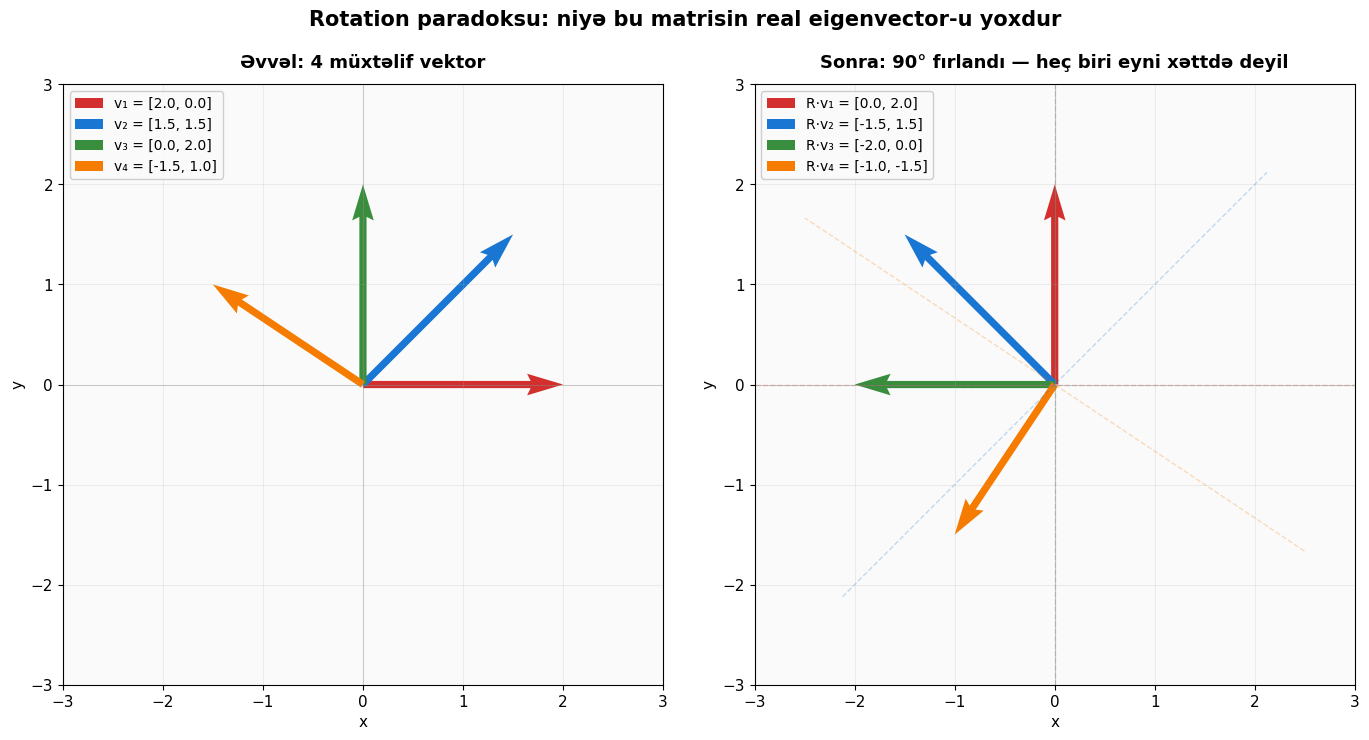


🔍 RƏQƏMSAL SÜBUT
R matrisinin eigenvalue-ları: [0.+1.j 0.-1.j]
   ↑ Bu kompleks ədədlərdir (i = xəyali vahid)

Real müstəvidə heç bir vektor 90° fırlandıqdan sonra
eyni xətt üzərində qalmır — buna görə real eigenvector yoxdur.

Kompleks aləmdə isə var: λ = ±i, və bu, fırlanma bucağını kodlayır.


In [14]:
import numpy as np
import matplotlib.pyplot as plt

# Stil
plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor'] = '#fafafa'
plt.rcParams['font.size'] = 11

# 90° fırlanma matrisi
R = np.array([[0, -1], [1, 0]])

# 4 sınaq vektoru — müxtəlif istiqamətlərdə
vektorlar = [
    np.array([2.0, 0.0]),    # sağa
    np.array([1.5, 1.5]),    # sağ-yuxarı
    np.array([0.0, 2.0]),    # yuxarı
    np.array([-1.5, 1.0]),   # sol-yuxarı
]

renglər = ['#d32f2f', '#1976d2', '#388e3c', '#f57c00']
adlar = ['v₁', 'v₂', 'v₃', 'v₄']

# İKİ ŞƏKİL YAN-YANA
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# ========== SOL: ORİJİNAL ==========
ax = axes[0]

for i, v in enumerate(vektorlar):
    ax.quiver(0, 0, v[0], v[1], angles='xy', scale_units='xy', scale=1,
              color=renglər[i], width=0.012, label=f'{adlar[i]} = {v.tolist()}')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
ax.set_title('Əvvəl: 4 müxtəlif vektor',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.set_xlabel('x')
ax.set_ylabel('y')

# ========== SAĞ: 90° FIRLANMADAN SONRA ==========
ax = axes[1]

for i, v in enumerate(vektorlar):
    # Orijinal istiqamətin kəsik xətti — "bax, burada idi"
    t = np.linspace(-3, 3, 100)
    norm_v = v / np.linalg.norm(v)
    ax.plot(t * norm_v[0], t * norm_v[1], '--',
            color=renglər[i], alpha=0.25, linewidth=1)
    
    # 90° fırlandıqdan sonrakı vektor
    Rv = R @ v
    ax.quiver(0, 0, Rv[0], Rv[1], angles='xy', scale_units='xy', scale=1,
              color=renglər[i], width=0.012, 
              label=f'R·{adlar[i]} = {Rv.tolist()}')

ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
ax.grid(True, alpha=0.2)
ax.set_aspect('equal')
ax.set_title('Sonra: 90° fırlandı — heç biri eyni xəttdə deyil',
             fontsize=13, fontweight='bold', pad=12)
ax.legend(loc='upper left', framealpha=0.95, fontsize=10)
ax.set_xlabel('x')
ax.set_ylabel('y')

# Ümumi başlıq
fig.suptitle('Rotation paradoksu: niyə bu matrisin real eigenvector-u yoxdur',
             fontsize=15, fontweight='bold', y=1.02)

plt.tight_layout()
plt.savefig('rotation_paradox.png', dpi=150, bbox_inches='tight')
plt.show()

# Rəqəmsal sübut
print("\n🔍 RƏQƏMSAL SÜBUT")
print("=" * 40)
eigenvalues, eigenvectors = np.linalg.eig(R)
print(f"R matrisinin eigenvalue-ları: {eigenvalues}")
print(f"   ↑ Bu kompleks ədədlərdir (i = xəyali vahid)")
print(f"\nReal müstəvidə heç bir vektor 90° fırlandıqdan sonra")
print(f"eyni xətt üzərində qalmır — buna görə real eigenvector yoxdur.")
print(f"\nKompleks aləmdə isə var: λ = ±i, və bu, fırlanma bucağını kodlayır.")

### Nə görürük?

İki şəkil 90° fırlanma matrisinin **R = [[0,-1],[1,0]]** davranışını göstərir:

- **Sol**: 4 müxtəlif istiqamətdə vektor
- **Sağ**: hər biri 90° saat əqrəbinin əksinə fırlanıb. Kəsik xətlər vektorların **əvvəlki istiqamətini** göstərir — heç biri orada qalmayıb.

Hər vektor öz xəttindən tam çıxır. Yəni **eyni xətt üzərində qalan vektor yoxdur** — və bu, eigenvector tərifinə birbaşa ziddir.

### Riyazi məna

Eigenvector tərifi A·v = λ·v deyir. Real ədədlər aləmində bu tənliyin R matrisi üçün **həlli yoxdur**, çünki xarakteristik tənlik belə olur:

$$\det(R - \lambda I) = \lambda^2 + 1 = 0$$

Bu tənlik real həlli olmayan tənlikdir (λ² = -1). Amma **kompleks ədədlər aləmində** həll var:

$$\lambda = \pm i$$

`np.linalg.eig(R)` bunu təsdiqləyir — eigenvalue-lar `0+1j` və `0-1j` çıxır. Bu kompleks ədədlər **təsadüfi deyil**: onlar Euler düsturu ilə fırlanma bucağını kodlayır:

$$e^{i\theta} = \cos\theta + i\sin\theta$$

90° fırlanma üçün θ = π/2, və eᶦᵖⁱ/² = i. Yəni eigenvalue özü fırlanma bucağıdır.

### Niyə vacibdir?

Bu paradoks bir vacib qaydanı öyrədir: **eigenvector həmişə real olmayacaq**. Bu, riyazi səhv deyil — sadəcə real müstəvidə bütün matrislərin "rahat" davranışı yoxdur.

Praktiki nəticələr:

- **Dinamik sistemlər**: kompleks eigenvalue-lar sistemdə **rəqs/oscillation** olduğunu göstərir (məs. yay-kütlə sistemi)
- **Signal processing**: Fourier analizində kompleks eigenvalue-lar tezlikləri ifadə edir
- **Kvant mexanikası**: kompleks ədədlər sistemin əsas dili — bütün operatorların eigenvalue-ları kompleks aləmdə yaşayır

Statistikada isə bu, **müsbət təyinatlı matrislərlə** (positive definite, məs. kovarians matrisləri) işləməyimizin səbəbidir — onların eigenvalue-ları **həmişə real** olduğu üçün PCA və oxşar alətlər problemsiz işləyir.

---

# 📝 FAZA 1 Yekunu: Vektor → Transformasiya → Determinant → Eigenvector

## Riyazi zəncir

FAZA 1 boyu xətti cəbrin əsas konseptləri **bir-birinin üstündə qurulan zəncir** kimi araşdırıldı. Hər addım əvvəlkini tələb edirdi, və hər biri özündən sonra gələn üçün zəmin hazırlayırdı.

### 1️⃣ Vektor — məkanın əsas dili

Vektor sadəcə bir ədədlər sırası deyil — **istiqamət və böyüklük** daşıyan həndəsi obyektdir. 2D vektor [a, b] x və y oxlarında müəyyən bir nöqtəyə işarə edir, amma daha vacib olan, onun **orijindən başlanan ox** kimi düşünülməsidir.

Vektorlar **toplanır** (paralelloqram qaydası) və **skalyarla vurulur** (uzanır/sıxılır). Bu iki əməliyyat bütün xətti cəbrin əsasıdır.

### 2️⃣ Transformasiya — vektorları çevirmək

Matris əslində bir **funksiyadır** — vektorları başqa vektorlara çevirir. A·v hesablamasının əsl mənası budur: "A matrisi v vektorunu hara aparır?".

Hər matris müəyyən bir **həndəsi əməliyyatı** kodlayır:
- Diaqonal matrislər: uzanma/sıxılma
- Fırlanma matrisləri: bucaq dəyişikliyi
- Shear matrisləri: əyilmə
- Ümumi matrislər: yuxarıdakıların kombinasiyası

Transformasiya konsepti vektoru "statik bir nöqtədən" **dinamik bir obyektə** çevirir.

### 3️⃣ Determinant — transformasiyanın "həcm faktoru"

Determinant matrisin **məkanı necə dəyişdirdiyini** ölçür:

- |det(A)| = 1: həcm qorunur (məs. fırlanma)
- |det(A)| > 1: məkan genişlənir
- |det(A)| < 1: məkan sıxılır
- det(A) = 0: məkan bir aşağı ölçüyə "çökür" (singular matris)
- det(A) < 0: oriyentasiya tərsinə çevrilir (güzgü əksi)

Determinant bizə deyir ki, transformasiya **geri qaytarıla bilərmi** — det(A) = 0 olarsa, vektor məlumatı qismən itirilir və A⁻¹ mövcud deyil.

### 4️⃣ Eigenvector — transformasiyanın "təbii oxları"

Eigenvector bir matrisin **istiqamətini dəyişmədiyi** xüsusi vektordur:

$$A \cdot v = \lambda \cdot v$$

Bu zəncirin zirvəsidir. Çünki:

- **Vektor** olmasaydı, transformasiyanın hara işlədiyini müzakirə edə bilməzdik
- **Transformasiya** olmasaydı, "dəyişmir" anlayışının mənası olmazdı
- **Determinant** olmasaydı, matrisin "necə davrandığını" ölçə bilməzdik
- **Eigenvector** isə bütün bu məlumatı **matrisin gizli skeletinə** çevirir

Yəni eigenvector təsadüfi bir konsept deyil — o, əvvəlki üç anlayışın **təbii yekunudur**.

---

## 💡 Bu fazada nə öyrəndim

**Texniki bacarıqlar**:
- NumPy ilə vektor və matris əməliyyatları (`@`, `np.dot`, `np.linalg`)
- Matplotlib-də 2D vektor vizualizasiyası (`quiver`, kovarians ellipsi)
- Eigenvalue/eigenvector hesablanması və `A·v = λ·v` yoxlanışı
- Animasiya ilə kəsilməz transformasiyanın göstərilməsi (`FuncAnimation`)
- Kovarians matrisinin əl ilə hesablanması və `np.cov` ilə müqayisəsi

**Konseptual başa düşmə**:
- Matrisi statik "ədədlər cədvəli" yox, **həndəsi funksiya** kimi görmək
- Eigenvector-un nə zaman **olmadığını** (fırlanma matrisləri) və niyə kompleks ədədlərin çıxdığını
- PCA-nın xətti cəbrin **birbaşa nəticəsi** olduğunu — yeni alət deyil, eyni konseptin tətbiqi
- **Karpathy qaydası**: alqoritmləri əvvəl əl ilə yazıb sonra kitabxana ilə yoxlamağın dəyəri

---

## 🎯 Növbəti addım: FAZA 2

FAZA 1 **2D müstəvi** ilə məhdud idi — vektorlar [a, b] formasında idi. FAZA 2-də zəncir daha da uzanır:

- **Projection və ortogonal komponentlər**: vektoru bir alt-məkana "endirmək"
- **Gram-Schmidt prosesi**: müstəqil oxlar qurmaq
- **SVD (Singular Value Decomposition)**: eigenvector-un ən qüdrətli ümumiləşməsi — istənilən matris üçün işləyir
- **Least squares**: real datanın **xətti modellə uyğunlaşdırılması**
- **Yüksək ölçülər**: 2D-dən n-D-yə keçid, və bunun nəticələri

SVD xüsusilə vacibdir — o, eigenvector konseptini **kvadrat olmayan matrislərə** də şamil edir, və müasir ML-də (tövsiyə sistemləri, embeddings, transformer modelləri) hər yerdə qarşıma çıxacaq.

---

## ✨ Tapındığım vacib intuisiyalar

1. **Eigenvector istisna deyil — o, matrisin əsl xarakteridir.** Hər transformasiya "fırlanma + uzanma" kimi düşünülə bilər. Eigenvector-lar **fırlanma sıfır** olan istiqamətlərdir. Bunu görəndən sonra matrislər birdən "şəxsiyyət" qazandı.

2. **Kompleks ədədlər səhv deyil — onlar mesajdır.** Fırlanma matrisinin kompleks eigenvalue-su deməkdir ki, "bu transformasiyada sırf uzanma yoxdur, fırlanma var". Riyaziyyat bizə öz dilində danışır.

3. **PCA təsadüfi tapılmış alət deyil.** O, "kovarians matrisinin eigenvector-larına bax" deməkdir — yəni datanın **öz xətti cəbri** ona deyir ki, hansı istiqamətlər vacibdir. Bu, statistikanı xətti cəbrin **tətbiq sahəsi** olaraq göstərir.

4. **Karpathy qaydası işləyir.** Hər alqoritmi əvvəl əl ilə yazıb sonra NumPy ilə yoxlamaq — bu, mexaniki başa düşməni qazandırır. `np.cov` bir qara qutu deyil, mənim üçün indi `(X^T X) / (n-1)` formuludur.

---

*Bu notebook `linear-algebra-journey` reposunun FAZA 1 hissəsini yekunlaşdırır. Növbəti hissə: `week05_projection_and_svd.ipynb`.*